In [1]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
# para normalização - MinMaxScaler
# para padronização normal - StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold,  cross_validate
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, accuracy_score, precision_score, recall_score, f1_score,roc_curve, roc_auc_score

from plot_aux import plot_bar_list_features, plot_boxplots_by_columns, plot_by_columns, plot_boxplots_by_columns_hue, plot_bar_list_features
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [4]:
df['blood_glucose_level'] = df['blood_glucose_level'].astype(float)

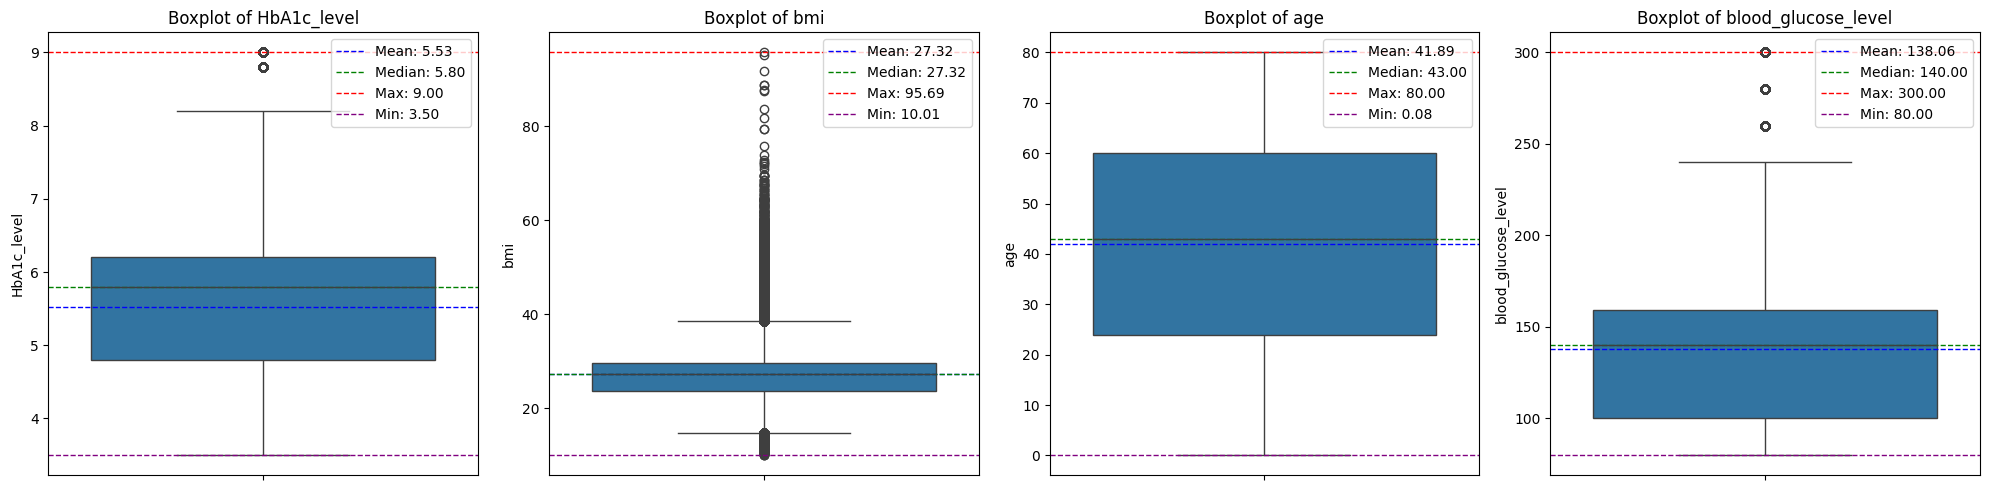

In [5]:
features_list = df.select_dtypes("float").columns.tolist()
plot_boxplots_by_columns(df,features_list)

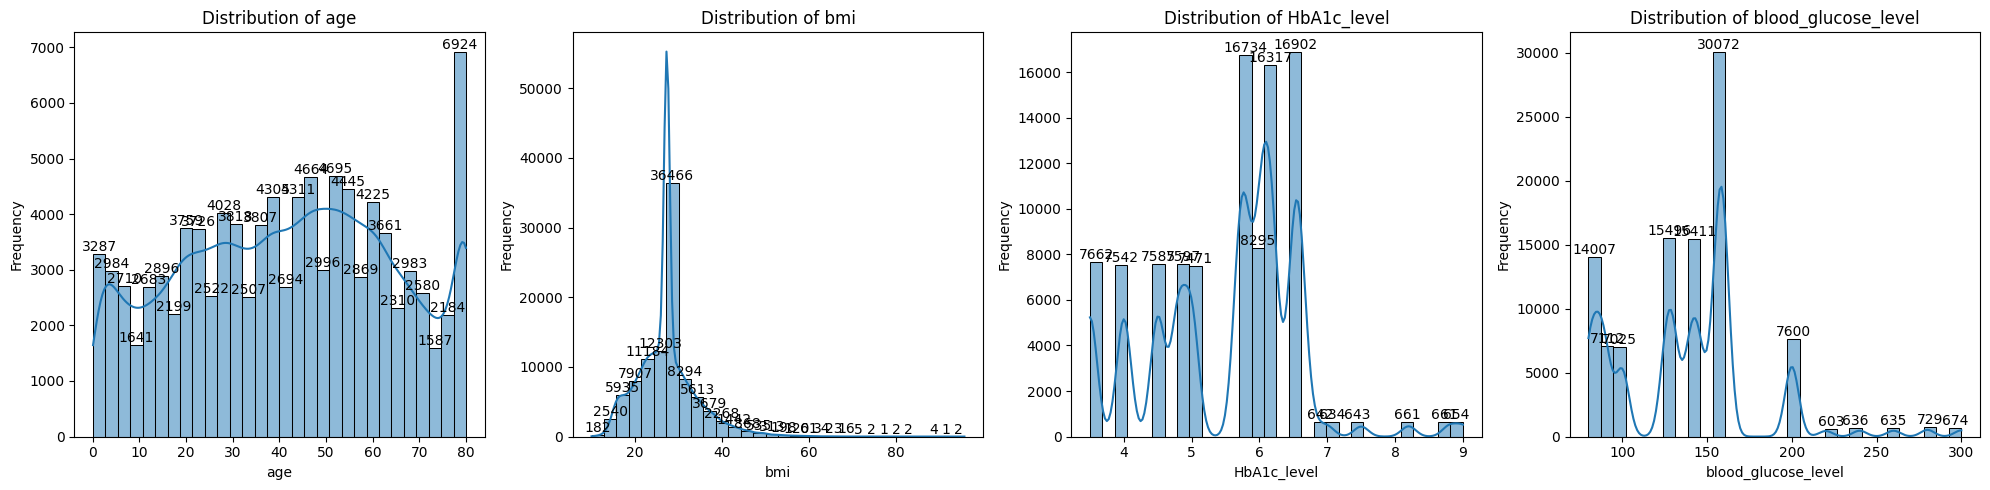

In [6]:
plot_by_columns(df,features_list)

In [8]:
string_features =  df.select_dtypes("object").columns.tolist()
string_features_bool = df.select_dtypes("int").columns.tolist()
string_features_bool.remove('diabetes')

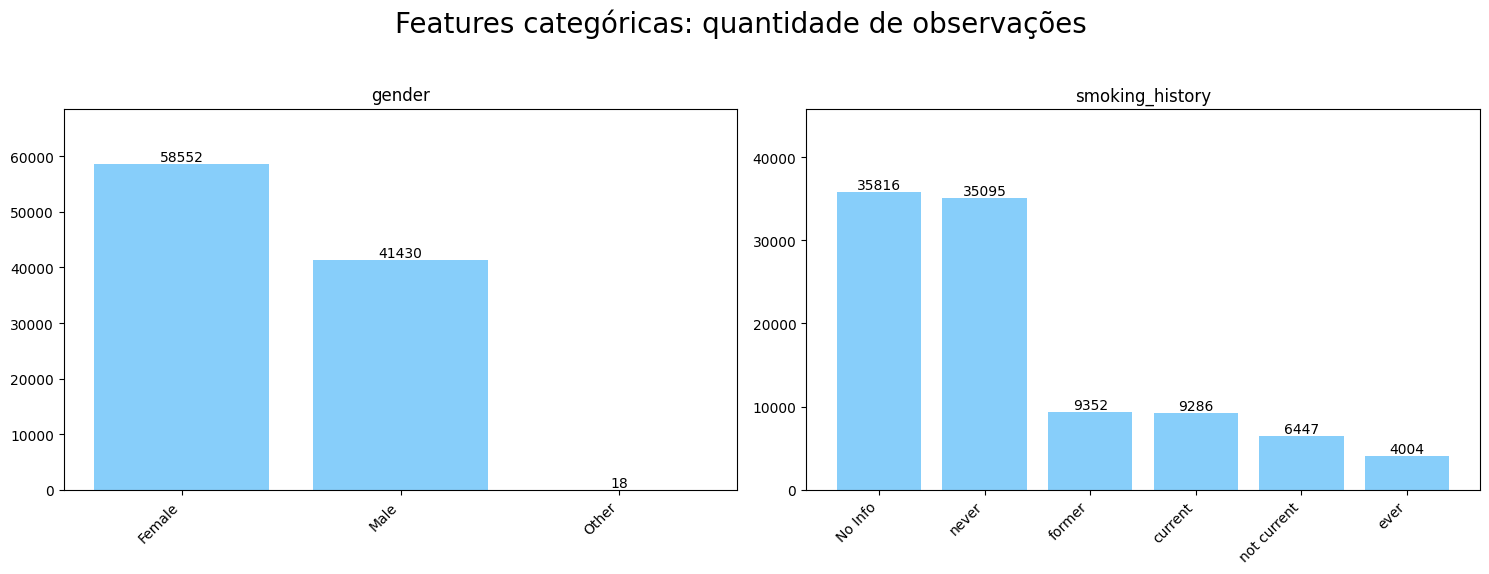

In [9]:
plot_bar_list_features(df=df, feature_list = string_features)

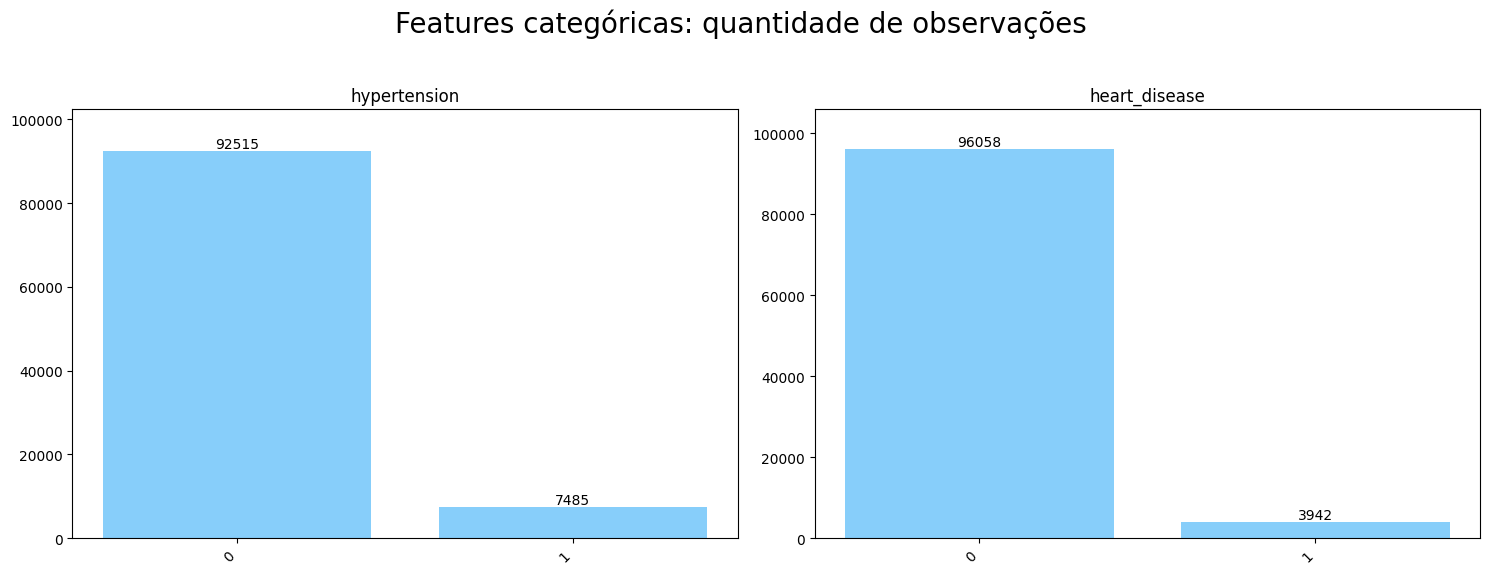

In [10]:
plot_bar_list_features(df=df, feature_list = string_features_bool)

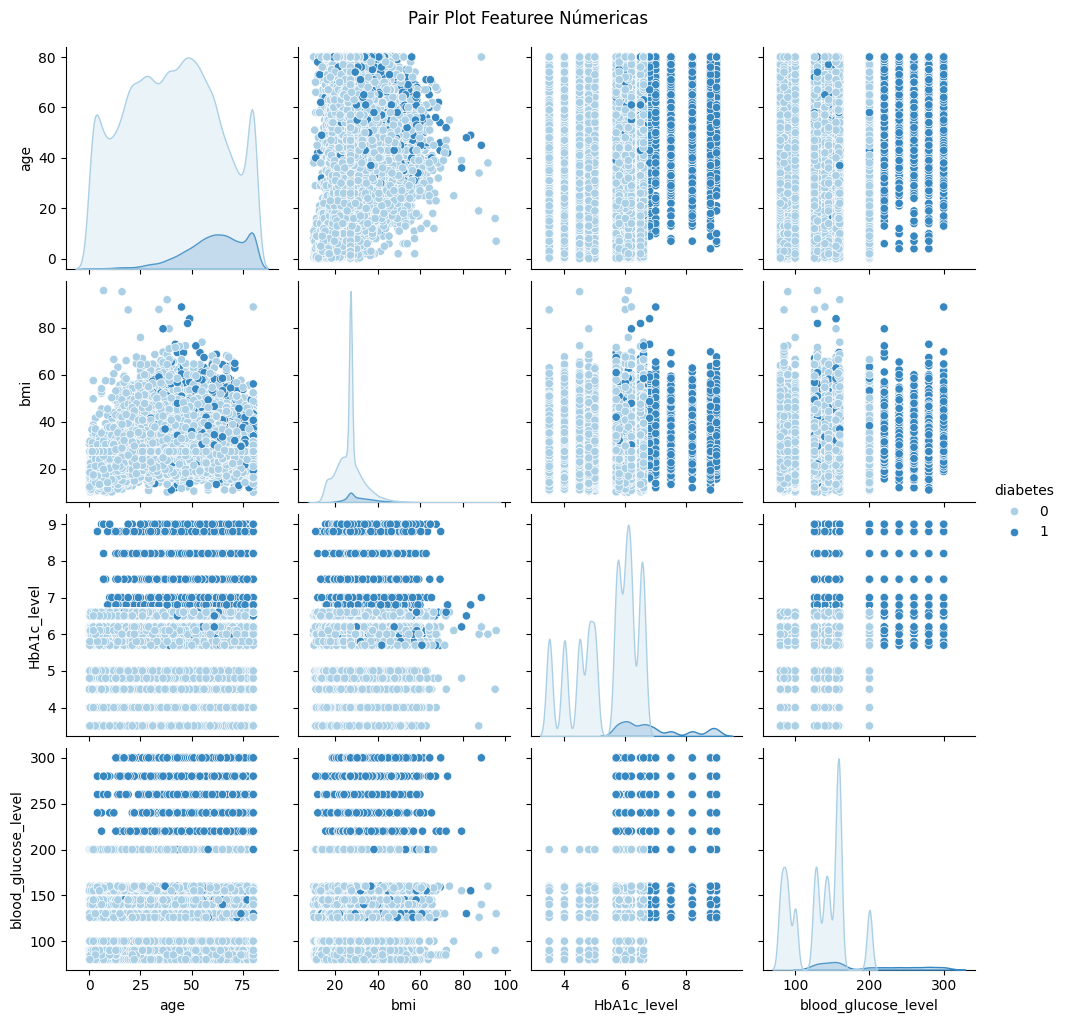

In [7]:
sns.pairplot(df[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']], hue='diabetes', palette='Blues')
plt.suptitle('Pair Plot Featuree Númericas', y=1.02) 
plt.show()

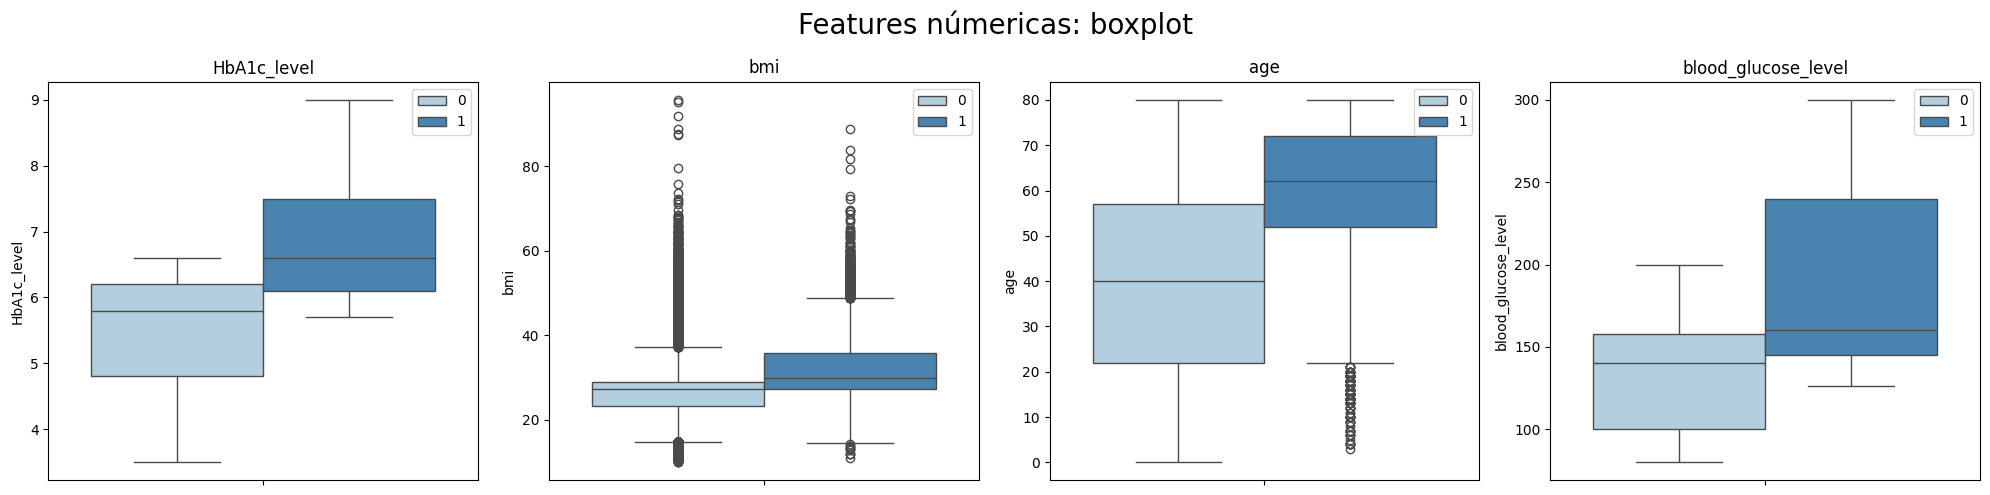

In [11]:
plot_boxplots_by_columns_hue(
    df=df, 
    column_names=['age', 'bmi', 'HbA1c_level', 'blood_glucose_level'], 
    hue='diabetes')

In [27]:
correlation_matrix = df[['age',  'bmi', 'HbA1c_level', 'blood_glucose_level','diabetes']].corr(method='pearson')

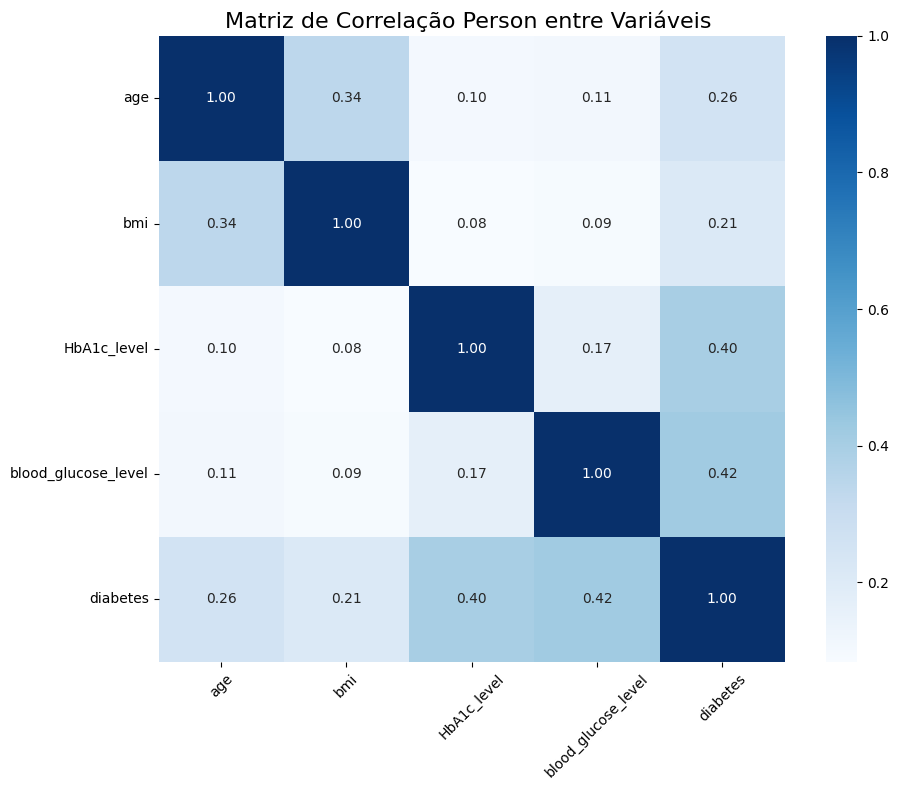

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="Blues", cbar=True, square=True)
plt.title("Matriz de Correlação Person ", fontsize=16)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

In [19]:
string_features_bool

['hypertension', 'heart_disease']

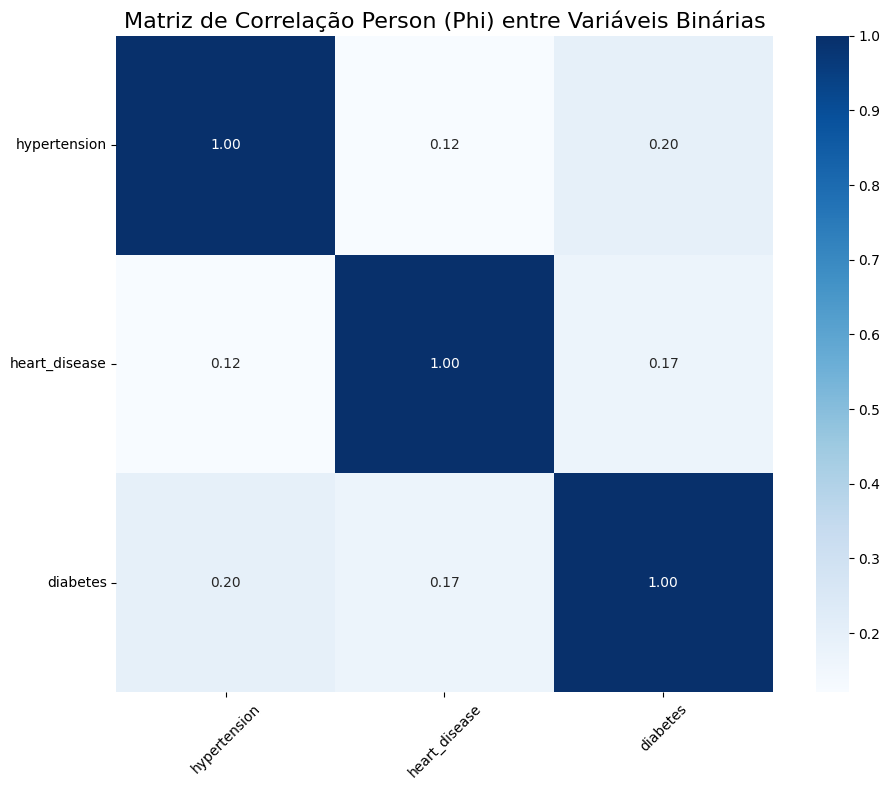

In [ ]:
correlation_matrix_binary = df[['hypertension', 'heart_disease','diabetes']].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_binary, annot=True, fmt=".2f", cmap="Blues", cbar=True, square=True)
plt.title("Matriz de Correlação Person (Phi) entre Variáveis Binárias", fontsize=16)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()
